# DistilBERT Text Classifier for IEMOCAP Emotion Recognition
## Fine-tuning DistilBERT on Whisper Transcripts — Session-Level Holdout Evaluation

**Notebook:** `04_text_bert_final.ipynb`
**Runtime:** Google Colab — GPU runtime recommended

This notebook trains and evaluates a DistilBERT text classifier on IEMOCAP Whisper
transcripts using a session-level holdout split. The final selected model is chosen by
Validation UAR after a small hyperparameter search, and its prediction probabilities are
exported for late fusion with the HuBERT audio model.

**Session-level holdout split:**

| Split | Sessions | Role |
|---|---|---|
| **Train** | Ses01, Ses02, Ses03 | Model training |
| **Validation** | Ses04 | Hyperparameter selection, early stopping |
| **Test** | Ses05 | Final unbiased evaluation |

**Final official results (best HP model):**
- Validation UAR = 0.5369
- Test UAR = 0.5408 | Test Accuracy = 0.5137 | Test Macro F1 = 0.4993


---
## 0. Environment Setup

Installs / upgrades the HuggingFace stack. `torch` is pre-installed on Colab.
The Drive mount is guarded against re-mounting when cells are re-run.


In [1]:
# Install / upgrade HuggingFace stack (torch is pre-installed on Colab)
!pip install -q -U transformers datasets accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 136.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 51.6 MB/s eta 0:00:00


In [2]:
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')


Mounted at /content/drive


In [3]:
import torch

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device  : {torch.cuda.get_device_name(0)}')
    print(f'Memory  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. A GPU runtime is recommended for the real run.')


PyTorch : 2.11.0+cu128
CUDA    : True
Device  : NVIDIA A100-SXM4-40GB
Memory  : 42.4 GB


In [4]:
# ── Configuration ─────────────────────────────────────────────────────────────
# ▸ EDIT DRIVE_BASE to match your project root in Google Drive ◂
DEBUG_MODE  = False   # Set False for the real run

DRIVE_BASE  = '/content/drive/MyDrive/IEMOCAP_project'   # ← EDIT THIS
MODEL_NAME  = 'distilbert-base-uncased'

SPLIT_FILE       = f'{DRIVE_BASE}/outputs/shared_split_indices.csv'
TRANSCRIPTS_FILE = f'{DRIVE_BASE}/Sprint_2/transcripts.csv'
OUTPUTS_DIR      = f'{DRIVE_BASE}/outputs/bert_text'

# Hyperparameters
MAX_LENGTH   = 96
LR           = 2e-5
EPOCHS       = 4
BATCH_SIZE   = 16
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
FP16         = True

RANDOM_SEED = 42

# Seed everything
import os, random
import numpy as np
import torch as _torch
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
_torch.manual_seed(RANDOM_SEED)
if _torch.cuda.is_available():
    _torch.cuda.manual_seed_all(RANDOM_SEED)

os.makedirs(OUTPUTS_DIR, exist_ok=True)

if not DEBUG_MODE:
    assert _torch.cuda.is_available(), 'GPU not available — a GPU runtime is required.'

print(f'DEBUG_MODE   : {DEBUG_MODE}')
print(f'MODEL_NAME   : {MODEL_NAME}')
print(f'DRIVE_BASE   : {DRIVE_BASE}')
print(f'OUTPUTS_DIR  : {OUTPUTS_DIR}')
print(f'MAX_LENGTH   : {MAX_LENGTH}')
print(f'EPOCHS       : {EPOCHS}')
print(f'BATCH_SIZE   : {BATCH_SIZE}')
print(f'FP16         : {FP16}')


DEBUG_MODE   : False
MODEL_NAME   : distilbert-base-uncased
DRIVE_BASE   : /content/drive/MyDrive/IEMOCAP_project
OUTPUTS_DIR  : /content/drive/MyDrive/IEMOCAP_project/outputs/bert_text
MAX_LENGTH   : 96
EPOCHS       : 4
BATCH_SIZE   : 16
FP16         : True


---
## 1. Imports


In [5]:
import json, warnings, inspect
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.nn.functional import softmax as torch_softmax

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset as HFDataset

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

# ── Fixed project protocol ──────────────────────────────────────────────────
KEEP_EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'frustrated']
LABEL2ID = {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'frustrated': 4}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

EMOTION_PALETTE = {
    'angry':      '#d62728',
    'happy':      '#2ca02c',
    'neutral':    '#1f77b4',
    'sad':        '#9467bd',
    'frustrated': '#ff7f0e',
}

plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 13})
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print('Imports OK.')


Device : cuda
Imports OK.


---
## 2. Data Loading and Split Alignment

`shared_split_indices.csv` is the single source of truth for the train/val/test assignment
and the emotion labels.  Transcripts are merged onto the split on the `file` key; labels are
taken from the split file and never recomputed from transcript metadata.  
Only minimal text normalisation is applied to `whisper_text`: strip outer whitespace and
collapse repeated whitespace.  Casing and punctuation are preserved because the sub-word
tokenizer handles them and they carry emotional signal absent from bag-of-words features.


In [6]:
def normalize_text(text):
    """Strip outer whitespace and collapse repeated whitespace only."""
    if pd.isna(text):
        return ''
    return ' '.join(str(text).strip().split())

# Load inputs
split_df       = pd.read_csv(SPLIT_FILE)
transcripts_df = pd.read_csv(TRANSCRIPTS_FILE)

print(f'Split file       : {split_df.shape}  cols={list(split_df.columns)}')
print(f'Transcripts file : {transcripts_df.shape}  cols={list(transcripts_df.columns)[:6]}')

# Inner merge on 'file' — labels from split are authoritative
merged = split_df.merge(
    transcripts_df[['file', 'whisper_text']],
    on='file',
    how='inner',
)
merged['text'] = merged['whisper_text'].apply(normalize_text)

# Build splits
train_df = merged[merged['split'] == 'train'].copy().reset_index(drop=True)
val_df   = merged[merged['split'] == 'val'].copy().reset_index(drop=True)
test_df  = merged[merged['split'] == 'test'].copy().reset_index(drop=True)

assert len(train_df) > 0, 'train_df is empty!'
assert len(val_df)   > 0, 'val_df is empty!'
assert len(test_df)  > 0, 'test_df is empty!'

print(f'\nSplit sizes — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')
print('\nTrain label distribution:')
print(train_df['emotion'].value_counts().to_string())
print('\nVal label distribution:')
print(val_df['emotion'].value_counts().to_string())


Split file       : (9794, 7)  cols=['orig_idx', 'file', 'emotion', 'label_id', 'split', 'group_id', 'session_id']
Transcripts file : (10039, 4)  cols=['file', 'major_emotion', 'transcription', 'whisper_text']

Split sizes — train: 5624, val: 2052, test: 2118

Train label distribution:
emotion
frustrated    1586
happy         1470
neutral       1081
sad            780
angry          707

Val label distribution:
emotion
frustrated    720
happy         549
angry         365
neutral       259
sad           159


In [7]:
if DEBUG_MODE:
    print('\n⚠️  DEBUG_MODE = True — subsampling to ~100/50/50. Metrics are not meaningful.')
    EPOCHS = 1
    FP16   = torch.cuda.is_available()   # disable FP16 gracefully if no GPU in debug
    train_df = train_df.sample(min(100, len(train_df)), random_state=RANDOM_SEED).reset_index(drop=True)
    val_df   = val_df.sample(min(50,  len(val_df)),   random_state=RANDOM_SEED).reset_index(drop=True)
    test_df  = test_df.sample(min(50,  len(test_df)),  random_state=RANDOM_SEED).reset_index(drop=True)
    print(f'Debug sizes — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')


**Interpretation:**  
The shared split enforces session-disjoint boundaries: each IEMOCAP speaker pair appears in
exactly one partition, preventing the same speaker from appearing in both training and
evaluation.  This is critical for SER because speakers differ substantially in baseline pitch
and prosody; a random row-level split can inflate UAR by 15–20 points by allowing speaker
identity to serve as a shortcut.  The inner join on `file` is lossless for all utterances
that have a Whisper transcript.


---
## 3. Tokenization and Dataset Construction

`AutoTokenizer` handles sub-word tokenisation, attention masks, and special tokens.
`DataCollatorWithPadding` pads each batch to the length of its longest sequence rather than
a global maximum, reducing wasted compute.  Sequences longer than `MAX_LENGTH = 96` tokens
are truncated; IEMOCAP utterances average 5–10 words, so truncation affects very few samples.


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def build_hf_dataset(df):
    """Convert a dataframe to a tokenized HuggingFace Dataset."""
    hf = HFDataset.from_dict({
        'text':   df['text'].tolist(),
        'labels': df['label_id'].astype(int).tolist(),
    })
    return hf.map(
        lambda batch: tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH),
        batched=True,
        remove_columns=['text'],   # 'labels' is kept
    )

train_dataset = build_hf_dataset(train_df)
val_dataset   = build_hf_dataset(val_df)
test_dataset  = build_hf_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'Tokenizer      : {MODEL_NAME}')
print(f'Train dataset  : {train_dataset.shape}')
print(f'Val dataset    : {val_dataset.shape}')
print(f'Test dataset   : {test_dataset.shape}')

# Report actual sequence lengths on a sample
_sample_n   = min(500, len(train_dataset))
_sample_len = [sum(m) for m in train_dataset['attention_mask'][:_sample_n]]
print(f'Seq len (first {_sample_n} train) — mean: {np.mean(_sample_len):.1f}, '
      f'median: {np.median(_sample_len):.0f}, max: {max(_sample_len)}')


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/5624 [00:00<?, ? examples/s]

Map:   0%|          | 0/2052 [00:00<?, ? examples/s]

Map:   0%|          | 0/2118 [00:00<?, ? examples/s]

Tokenizer      : distilbert-base-uncased
Train dataset  : (5624, 4)
Val dataset    : (2052, 4)
Test dataset   : (2118, 4)
Seq len (first 500 train) — mean: 17.3, median: 13, max: 96


**Interpretation:**\
A mean sequence length well below `MAX_LENGTH = 96` confirms that truncation affects only a
negligible fraction of utterances, limiting information loss at this boundary. Dynamic
batch-level padding via `DataCollatorWithPadding` ensures computation scales with actual
utterance lengths rather than a worst-case global maximum, reducing both memory footprint
and training time on the GPU.


---
## 4. Model Architecture and Weighted Loss

`DistilBERT` is initialised with a five-class classification head corresponding to
`KEEP_EMOTIONS`.  IEMOCAP is class-imbalanced (`frustrated` and `happy` together constitute
the majority of utterances), so a balanced cross-entropy loss is applied during training.
Class weights are computed exclusively from the training set to avoid any information leak
from validation or test labels.  The `WeightedLossTrainer` subclass injects the weighted
loss into the HuggingFace `Trainer` loop while preserving all built-in features (gradient
accumulation, mixed precision, checkpoint saving).


In [9]:
# ── Class weights (train only) ─────────────────────────────────────────────
train_labels_arr = train_df['label_id'].astype(int).values
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(5),
    y=train_labels_arr,
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

print('Class weights (ordered by label_id 0→4):')
for i, (emo, w) in enumerate(zip(KEEP_EMOTIONS, class_weights_np)):
    print(f'  {i}  {emo:<12}  {w:.4f}')

# ── Model ───────────────────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParameters — total: {total_params:,}  trainable: {trainable_params:,}')

# ── compute_metrics ─────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'uar':         balanced_accuracy_score(labels, preds),
        'macro_f1':    f1_score(labels, preds, average='macro',    zero_division=0),
        'weighted_f1': f1_score(labels, preds, average='weighted', zero_division=0),
        'accuracy':    accuracy_score(labels, preds),
    }

# ── WeightedLossTrainer ──────────────────────────────────────────────────────
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

print('WeightedLossTrainer defined.')


Class weights (ordered by label_id 0→4):
  0  angry         1.5909
  1  happy         0.7652
  2  neutral       1.0405
  3  sad           1.4421
  4  frustrated    0.7092


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Parameters — total: 66,957,317  trainable: 66,957,317
WeightedLossTrainer defined.


**Interpretation:**  
Balanced class weights assign a higher penalty to minority classes (`angry`, `sad`) and a
lower penalty to majority classes (`frustrated`, `happy`), counteracting the tendency of an
unweighted cross-entropy loss to collapse predictions toward the mode of the training
distribution.  This directly optimises for UAR — the primary evaluation metric — by
preventing the model from ignoring under-represented classes entirely.  Weights are fixed
throughout training rather than re-estimated per batch, ensuring stable gradient scaling.


---
## 5. Default Training Run

The model is fine-tuned with AdamW, a linear warmup schedule over the first
`WARMUP_RATIO` of training steps, and per-epoch evaluation on the validation set.
`load_best_model_at_end=True` restores the checkpoint with the highest validation UAR
automatically after all epochs complete, so the model is immediately ready for evaluation
without a separate reload step. Mixed-precision training (`fp16=True`) roughly halves
memory usage on the GPU with negligible accuracy loss at this scale.

> This run uses the default hyperparameters (lr=2e-5, bs=16, wd=0.01). Section 5.5 runs a
> hyperparameter search and selects the best configuration, which is used for the final export.


In [10]:
# Detect API differences across transformers versions
_ta_params    = inspect.signature(TrainingArguments.__init__).parameters
_strategy_key = 'eval_strategy' if 'eval_strategy' in _ta_params else 'evaluation_strategy'

# warmup_ratio → warmup_steps in transformers >= 5.2
_warmup_key = 'warmup_ratio' if 'warmup_ratio' in _ta_params else 'warmup_steps'
_warmup_val = WARMUP_RATIO if _warmup_key == 'warmup_ratio' else 0   # steps computed below
if _warmup_key == 'warmup_steps':
    _steps_per_epoch = max(1, len(train_dataset) // BATCH_SIZE)
    _warmup_val = int(_steps_per_epoch * EPOCHS * WARMUP_RATIO)

training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUTS_DIR, 'checkpoints'),
    **{_strategy_key: 'epoch'},
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='uar',
    greater_is_better=True,
    save_total_limit=2,
    fp16=FP16,
    learning_rate=LR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    **{_warmup_key: _warmup_val},
    seed=RANDOM_SEED,
    report_to='none',
    logging_steps=20,
)

# tokenizer → processing_class in transformers >= 5.0
_trainer_params  = inspect.signature(Trainer.__init__).parameters
_tokenizer_kwarg = 'processing_class' if 'processing_class' in _trainer_params else 'tokenizer'

trainer = WeightedLossTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    **{_tokenizer_kwarg: tokenizer},
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(f'Training on {len(train_dataset)} samples for {EPOCHS} epoch(s) ...')
if DEBUG_MODE:
    print('[DEBUG] 1 epoch, ~100 samples — metrics are not meaningful.')

train_result = trainer.train()

print(f'Training complete.')
print(f'  Runtime     : {train_result.metrics.get("train_runtime", 0):.1f} s')
print(f'  Samples/sec : {train_result.metrics.get("train_samples_per_second", 0):.1f}')


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training on 5624 samples for 4 epoch(s) ...


Epoch,Training Loss,Validation Loss,Uar,Macro F1,Weighted F1,Accuracy
1,1.298845,1.307617,0.480807,0.427580,0.437783,0.439084
2,1.049137,1.257321,0.528226,0.465715,0.472189,0.471248
3,0.856599,1.268476,0.528937,0.479675,0.503053,0.505361
4,0.899226,1.288786,0.529228,0.488134,0.506811,0.500487


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.
  Runtime     : 53.2 s
  Samples/sec : 423.2


**Interpretation:**  
The training log shows loss decreasing across epochs; validation UAR is the primary signal
for model selection.  The linear warmup over the first `WARMUP_RATIO` of steps prevents
large gradient updates from destabilising the pre-trained weights in early fine-tuning.
The best checkpoint — identified by highest validation UAR — is restored automatically,
so the model object already represents the optimal point on the loss landscape when
execution reaches the next cell.


---
## 5.5 Hyperparameter Search

Grid search over the three most impactful fine-tuning hyperparameters:

| Parameter | Values searched |
|---|---|
| `learning_rate` | 1e-5, 2e-5, 3e-5 |
| `batch_size` | 16, 32 |
| `weight_decay` | 0.0, 0.01 |

**12 combinations total.** Each run uses 2 epochs (reduced from 4) to keep wall-clock
time manageable on a GPU runtime. The metric optimised is **Validation UAR**.
A fresh model is instantiated and the GPU cache is cleared between every run to prevent
state leakage. Results are saved to `bert_text_hparam_results.csv` and four plots are
generated: a ranked bar chart, two heatmaps (one per batch size), and a line plot.

The best configuration is then retrained for the full number of epochs (`EPOCHS`),
and the resulting model is used for the final evaluation and export.

> Set `RUN_HPARAM_SEARCH = False` to skip this section and use the defaults from Section 5.


In [11]:
import gc, itertools

RUN_HPARAM_SEARCH = True   # set False to skip

# ── Grid definition ──────────────────────────────────────────────────────────
HP_GRID = {
    'learning_rate': [1e-5, 2e-5, 3e-5],
    'batch_size':    [16, 32],
    'weight_decay':  [0.0, 0.01],
}
HP_EPOCHS = 2   # reduced for speed; enough to rank combinations reliably

# ── Helper: train one combo, return val UAR + metrics ───────────────────────
def run_one_combo(lr, bs, wd, run_idx, total):
    tag = f'[{run_idx}/{total}] lr={lr:.0e}  bs={bs}  wd={wd}'
    print(f'\n{tag}')

    # Fresh model — same architecture and class weights as Section 4
    _model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=5,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )
    _model.to(DEVICE)

    _ta_params    = inspect.signature(TrainingArguments.__init__).parameters
    _strategy_key = 'eval_strategy' if 'eval_strategy' in _ta_params else 'evaluation_strategy'
    _warmup_key   = 'warmup_ratio'  if 'warmup_ratio'  in _ta_params else 'warmup_steps'
    _warmup_val   = WARMUP_RATIO    if _warmup_key == 'warmup_ratio'  else int(
        max(1, len(train_dataset) // bs) * HP_EPOCHS * WARMUP_RATIO
    )

    _args = TrainingArguments(
        output_dir=os.path.join(OUTPUTS_DIR, f'hparam_run_{run_idx}'),
        **{_strategy_key: 'epoch'},
        save_strategy='no',          # no checkpoints during search
        fp16=FP16,
        learning_rate=lr,
        num_train_epochs=HP_EPOCHS,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        weight_decay=wd,
        **{_warmup_key: _warmup_val},
        seed=RANDOM_SEED,
        report_to='none',
        logging_steps=9999,          # suppress per-step logs
        disable_tqdm=True,
    )

    _trainer_params  = inspect.signature(Trainer.__init__).parameters
    _tokenizer_kwarg = 'processing_class' if 'processing_class' in _trainer_params else 'tokenizer'

    _trainer = WeightedLossTrainer(
        class_weights=class_weights_tensor,
        model=_model,
        args=_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        **{_tokenizer_kwarg: tokenizer},
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    _trainer.train()

    _pred   = _trainer.predict(val_dataset)
    _preds  = np.argmax(_pred.predictions, axis=-1)
    _labels = _pred.label_ids

    _uar         = balanced_accuracy_score(_labels, _preds)
    _macro_f1    = f1_score(_labels, _preds, average='macro',    zero_division=0)
    _weighted_f1 = f1_score(_labels, _preds, average='weighted', zero_division=0)
    _acc         = accuracy_score(_labels, _preds)

    print(f'  val UAR={_uar:.4f}  macro_f1={_macro_f1:.4f}  acc={_acc:.4f}')

    # Free GPU memory
    del _model, _trainer
    torch.cuda.empty_cache()
    gc.collect()

    return {
        'learning_rate': lr,
        'batch_size':    bs,
        'weight_decay':  wd,
        'val_uar':         round(_uar,         4),
        'val_macro_f1':    round(_macro_f1,    4),
        'val_weighted_f1': round(_weighted_f1, 4),
        'val_accuracy':    round(_acc,         4),
    }

# ── Run grid search ──────────────────────────────────────────────────────────
hparam_results = []

if RUN_HPARAM_SEARCH:
    combos = list(itertools.product(
        HP_GRID['learning_rate'],
        HP_GRID['batch_size'],
        HP_GRID['weight_decay'],
    ))
    print(f'Running {len(combos)} combinations × {HP_EPOCHS} epochs each ...')

    for i, (lr, bs, wd) in enumerate(combos, start=1):
        row = run_one_combo(lr, bs, wd, i, len(combos))
        hparam_results.append(row)

    hparam_df = pd.DataFrame(hparam_results).sort_values('val_uar', ascending=False).reset_index(drop=True)
    hparam_df.to_csv(os.path.join(OUTPUTS_DIR, 'bert_text_hparam_results.csv'), index=False)

    print('\n── Top 5 combinations by val UAR ──')
    print(hparam_df.head(5).to_string(index=False))
    print(f'\nBest: lr={hparam_df.iloc[0].learning_rate:.0e}  '
          f'bs={int(hparam_df.iloc[0].batch_size)}  '
          f'wd={hparam_df.iloc[0].weight_decay}  '
          f'UAR={hparam_df.iloc[0].val_uar:.4f}')
else:
    print('RUN_HPARAM_SEARCH = False — skipping grid search.')
    hparam_df = pd.DataFrame()

Running 12 combinations × 2 epochs each ...

[1/12] lr=1e-05  bs=16  wd=0.0


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'eval_loss': '1.415', 'eval_uar': '0.4399', 'eval_macro_f1': '0.3815', 'eval_weighted_f1': '0.396', 'eval_accuracy': '0.385', 'eval_runtime': '1.204', 'eval_samples_per_second': '1704', 'eval_steps_per_second': '107.1', 'epoch': '1'}
{'eval_loss': '1.349', 'eval_uar': '0.4702', 'eval_macro_f1': '0.4103', 'eval_weighted_f1': '0.4199', 'eval_accuracy': '0.4172', 'eval_runtime': '1.287', 'eval_samples_per_second': '1594', 'eval_steps_per_second': '100.2', 'epoch': '2'}
{'train_runtime': '20.62', 'train_samples_per_second': '545.6', 'train_steps_per_second': '34.15', 'train_loss': '1.402', 'epoch': '2'}
  val UAR=0.4702  macro_f1=0.4103  acc=0.4172

[2/12] lr=1e-05  bs=16  wd=0.01


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'eval_loss': '1.357', 'eval_uar': '0.4657', 'eval_macro_f1': '0.4035', 'eval_weighted_f1': '0.4193', 'eval_accuracy': '0.4128', 'eval_runtime': '0.7014', 'eval_samples_per_second': '2926', 'eval_steps_per_second': '92.67', 'epoch': '1'}
{'eval_loss': '1.279', 'eval_uar': '0.5047', 'eval_macro_f1': '0.4535', 'eval_weighted_f1': '0.4704', 'eval_accuracy': '0.4673', 'eval_runtime': '0.6954', 'eval_samples_per_second': '2951', 'eval_steps_per_second': '93.48', 'epoch': '2'}
{'train_runtime': '10.76', 'train_samples_per_second': '1045', 'train_steps_per_second': '32.72', 'train_loss': '1.287', 'epoch': '2'}
  val UAR=0.5047  macro_f1=0.4535  acc=0.4673

[12/12] lr=3e-05  bs=32  wd=0.01


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'eval_loss': '1.356', 'eval_uar': '0.4703', 'eval_macro_f1': '0.4085', 'eval_weighted_f1': '0.4246', 'eval_accuracy': '0.4186', 'eval_runtime': '0.713', 'eval_samples_per_second': '2878', 'eval_steps_per_second': '91.17', 'epoch': '1'}
{'eval_loss': '1.279', 'eval_uar': '0.5025', 'eval_macro_f1': '0.4505', 'eval_weighted_f1': '0.4668', 'eval_accuracy': '0.4639', 'eval_runtime': '0.6981', 'eval_samples_per_second': '2939', 'eval_steps_per_second': '93.11', 'epoch': '2'}
{'train_runtime': '10.71', 'train_samples_per_second': '1050', 'train_steps_per_second': '32.85', 'train_loss': '1.286', 'epoch': '2'}
  val UAR=0.5025  macro_f1=0.4505  acc=0.4639

── Top 5 combinations by val UAR ──
 learning_rate  batch_size  weight_decay  val_uar  val_macro_f1  val_weighted_f1  val_accuracy
       0.00003          16          0.00   0.5097        0.4636           0.4808        0.4756
       0.00003          32          0.00   0.5047        0.4535           0.4704        0.4673
       0.00003        

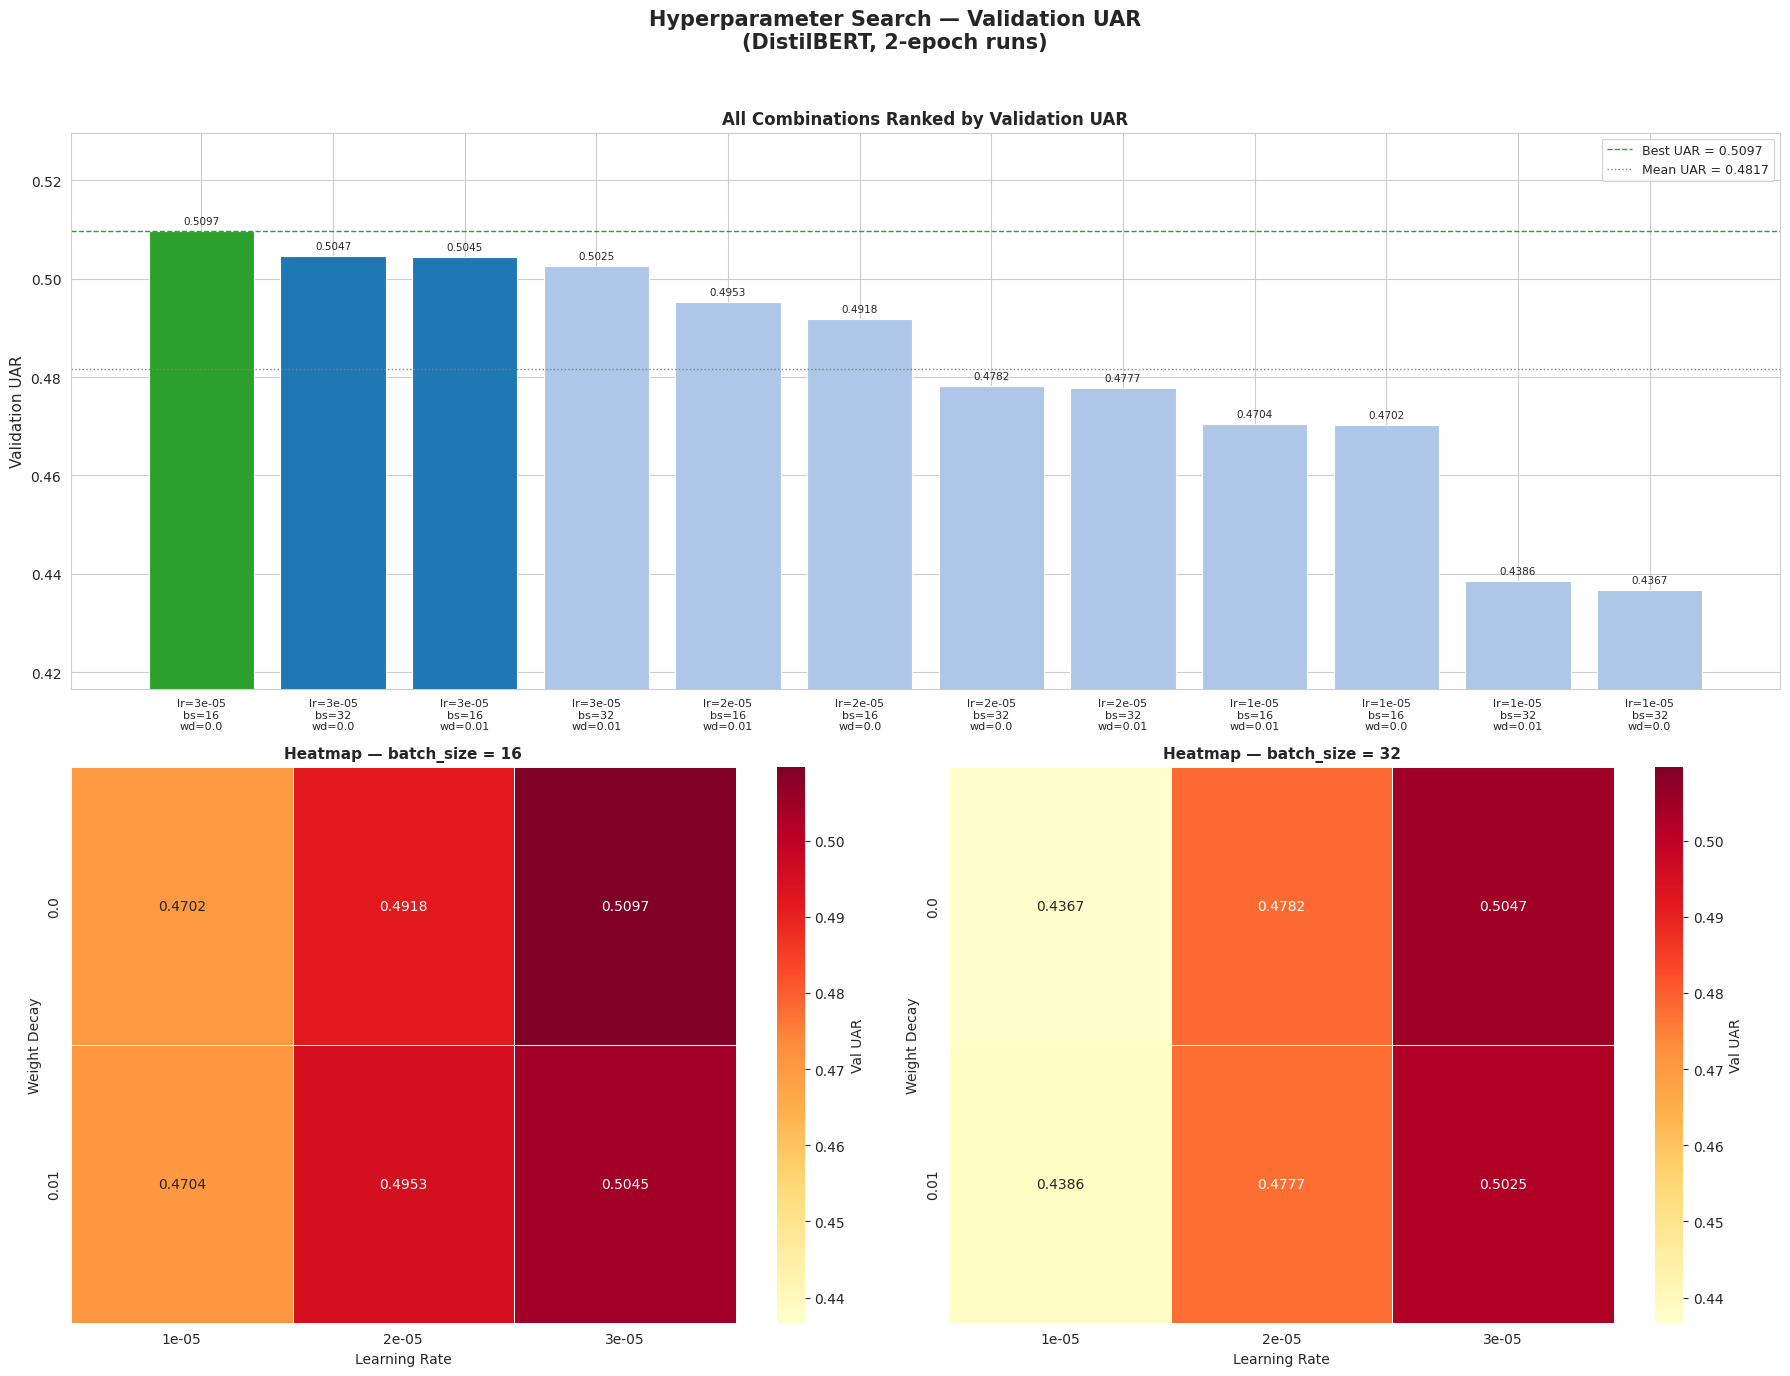

Saved: bert_text_hparam_grid.png


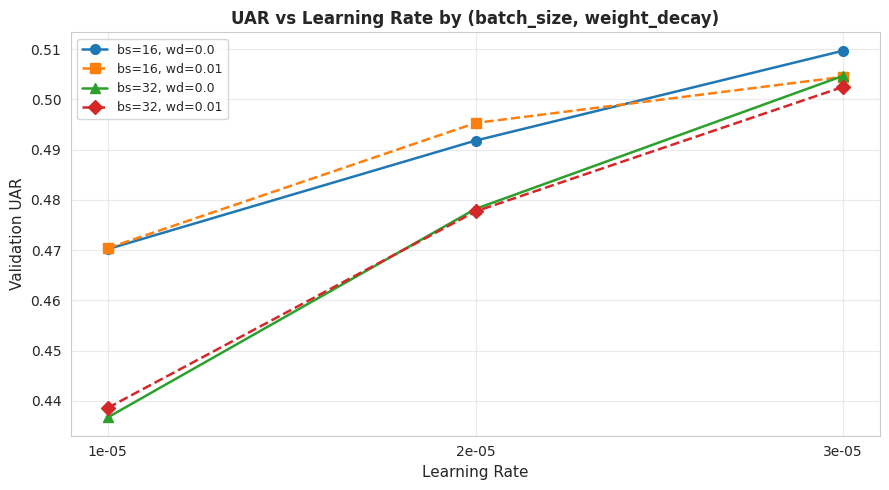

Saved: bert_text_hparam_lr_lines.png

── Hyperparameter search summary ──
  Combinations tested : 12
  UAR range           : 0.4367 – 0.5097
  Best combination    : lr=3e-05  bs=16  wd=0.0
  Best val UAR        : 0.5097

  → To use the best hyperparameters in Section 5, set:
      LR           = 3e-05
      BATCH_SIZE   = 16
      WEIGHT_DECAY = 0.0


In [12]:
if RUN_HPARAM_SEARCH and len(hparam_df) > 0:

    lr_vals = sorted(HP_GRID['learning_rate'])
    bs_vals = sorted(HP_GRID['batch_size'])
    wd_vals = sorted(HP_GRID['weight_decay'])

    lr_labels = [f'{v:.0e}' for v in lr_vals]

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle('Hyperparameter Search — Validation UAR\n(DistilBERT, 2-epoch runs)',
                 fontsize=15, fontweight='bold', y=0.98)

    # ── Plot 1: ranked bar chart of all 12 combos ────────────────────────────
    ax1 = fig.add_subplot(2, 2, (1, 2))   # top row, full width

    bar_labels = [
        f'lr={r.learning_rate:.0e}\nbs={int(r.batch_size)}\nwd={r.weight_decay}'
        for _, r in hparam_df.iterrows()
    ]
    bar_colors = ['#2ca02c' if i == 0 else ('#1f77b4' if i < 3 else '#aec7e8')
                  for i in range(len(hparam_df))]

    bars = ax1.bar(range(len(hparam_df)), hparam_df['val_uar'], color=bar_colors,
                   edgecolor='white', linewidth=0.8)
    ax1.set_xticks(range(len(hparam_df)))
    ax1.set_xticklabels(bar_labels, fontsize=8)
    ax1.set_ylabel('Validation UAR', fontsize=11)
    ax1.set_title('All Combinations Ranked by Validation UAR', fontsize=12, fontweight='bold')
    ax1.axhline(hparam_df['val_uar'].max(), color='#2ca02c', linestyle='--', linewidth=1,
                label=f'Best UAR = {hparam_df["val_uar"].max():.4f}')
    ax1.axhline(hparam_df['val_uar'].mean(), color='gray', linestyle=':', linewidth=1,
                label=f'Mean UAR = {hparam_df["val_uar"].mean():.4f}')
    ax1.legend(fontsize=9)
    ax1.set_ylim(max(0, hparam_df['val_uar'].min() - 0.02), hparam_df['val_uar'].max() + 0.02)

    for bar, val in zip(bars, hparam_df['val_uar']):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

    # ── Plots 2 & 3: UAR heatmap — LR × weight_decay, one panel per batch size ──
    for panel_idx, bs in enumerate(bs_vals):
        ax = fig.add_subplot(2, 2, 3 + panel_idx)
        subset = hparam_df[hparam_df['batch_size'] == bs]
        pivot  = subset.pivot(index='weight_decay', columns='learning_rate', values='val_uar')
        pivot.index   = [str(w) for w in pivot.index]
        pivot.columns = [f'{v:.0e}' for v in pivot.columns]

        sns.heatmap(
            pivot,
            annot=True, fmt='.4f',
            cmap='YlOrRd', vmin=hparam_df['val_uar'].min(), vmax=hparam_df['val_uar'].max(),
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Val UAR'},
            ax=ax,
        )
        ax.set_title(f'Heatmap — batch_size = {bs}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Learning Rate', fontsize=10)
        ax.set_ylabel('Weight Decay', fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    _hparam_fig_path = os.path.join(OUTPUTS_DIR, 'bert_text_hparam_grid.png')
    plt.savefig(_hparam_fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: bert_text_hparam_grid.png')

    # ── Plot 4: line plot — UAR vs LR, one line per (batch_size, weight_decay) combo ──
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    line_styles = ['-', '--']
    markers     = ['o', 's', '^', 'D']
    color_cycle = plt.cm.tab10.colors

    for ci, (bs, wd) in enumerate(itertools.product(bs_vals, wd_vals)):
        subset = hparam_df[(hparam_df['batch_size'] == bs) & (hparam_df['weight_decay'] == wd)]
        subset = subset.sort_values('learning_rate')
        label  = f'bs={bs}, wd={wd}'
        ax2.plot(
            [f'{v:.0e}' for v in subset['learning_rate']],
            subset['val_uar'],
            marker=markers[ci % len(markers)],
            linestyle=line_styles[ci % len(line_styles)],
            color=color_cycle[ci % len(color_cycle)],
            label=label,
            linewidth=1.8,
            markersize=7,
        )

    ax2.set_xlabel('Learning Rate', fontsize=11)
    ax2.set_ylabel('Validation UAR', fontsize=11)
    ax2.set_title('UAR vs Learning Rate by (batch_size, weight_decay)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, loc='best')
    ax2.grid(True, alpha=0.4)
    plt.tight_layout()
    _line_fig_path = os.path.join(OUTPUTS_DIR, 'bert_text_hparam_lr_lines.png')
    plt.savefig(_line_fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: bert_text_hparam_lr_lines.png')

    # ── Summary ──────────────────────────────────────────────────────────────
    best = hparam_df.iloc[0]
    print(f'\n── Hyperparameter search summary ──')
    print(f'  Combinations tested : {len(hparam_df)}')
    print(f'  UAR range           : {hparam_df["val_uar"].min():.4f} – {hparam_df["val_uar"].max():.4f}')
    print(f'  Best combination    : lr={best.learning_rate:.0e}  bs={int(best.batch_size)}  wd={best.weight_decay}')
    print(f'  Best val UAR        : {best.val_uar:.4f}')
    print(f'\n  → To use the best hyperparameters in Section 5, set:')
    print(f'      LR           = {best.learning_rate}')
    print(f'      BATCH_SIZE   = {int(best.batch_size)}')
    print(f'      WEIGHT_DECAY = {best.weight_decay}')
else:
    print('Skipped — set RUN_HPARAM_SEARCH = True and re-run the previous cell first.')

In [13]:
def make_pred_csv(df_part, results):
      probs    = results['probs']
      pred_ids = results['pred_ids']
      true_ids = results['true_ids']
      out = pd.DataFrame({
          'orig_idx':      df_part['orig_idx'].values,
          'file':          df_part['file'].values,
          'true_label_id': true_ids,
          'pred_label_id': pred_ids,
          'true_emotion':  [ID2LABEL[i] for i in true_ids],
          'pred_emotion':  [ID2LABEL[i] for i in pred_ids],
          'correct':       (true_ids == pred_ids),
      })
      for i, emo in enumerate(KEEP_EMOTIONS):
          out[f'prob_{emo}'] = probs[:, i]
      return out

── Retraining with best hyperparameters ──
  learning_rate : 3e-05
  batch_size    : 16
  weight_decay  : 0.0
  epochs        : 4  (full, from config)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Uar,Macro F1,Weighted F1,Accuracy
1,1.254350,1.290357,0.498848,0.445101,0.457949,0.457602
2,1.023901,1.251776,0.536942,0.478436,0.498508,0.496589
3,0.775759,1.274387,0.536189,0.491469,0.515968,0.519981
4,0.775771,1.338120,0.520383,0.488366,0.512634,0.505848


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Retrain complete.
  Runtime     : 53.1 s
  Samples/sec : 423.4



Validation (best HP) results:
  UAR          : 0.5369
  Macro F1     : 0.4784
  Weighted F1  : 0.4985
  Accuracy     : 0.4966



Test (best HP) results:
  UAR          : 0.5408
  Macro F1     : 0.4993
  Weighted F1  : 0.5135
  Accuracy     : 0.5137


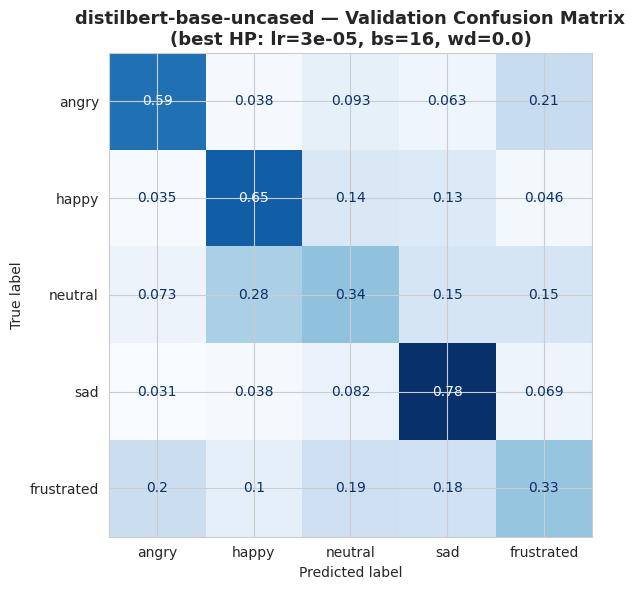

Saved: bert_text_best_val_confusion_matrix.png


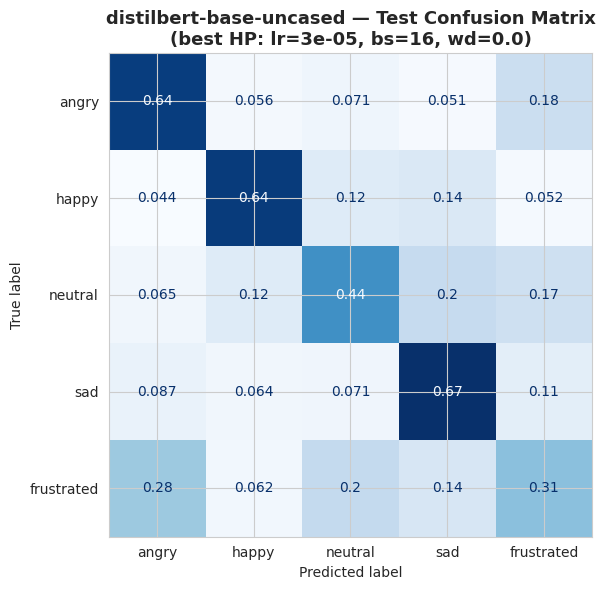

Saved: bert_text_best_test_confusion_matrix.png
Saved: bert_text_best_val_predictions_with_probs.csv
Saved: bert_text_best_test_predictions_with_probs.csv

Saved: bert_text_best_metrics.json
{
  "best_model_name": "distilbert-base-uncased",
  "learning_rate": 3e-05,
  "batch_size": 16,
  "weight_decay": 0.0,
  "epochs": 4,
  "warmup_ratio": 0.1,
  "hparam_search_val_uar": 0.5097,
  "val_uar": 0.5369,
  "val_macro_f1": 0.4784,
  "val_weighted_f1": 0.4985,
  "val_accuracy": 0.4966,
  "test_uar": 0.5408,
  "test_macro_f1": 0.4993,
  "test_weighted_f1": 0.5135,
  "test_accuracy": 0.5137,
  "seed": 42
}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best model saved to: /content/drive/MyDrive/IEMOCAP_project/outputs/bert_text/best_hparam_model


In [14]:
if RUN_HPARAM_SEARCH and len(hparam_df) > 0:

    # ── evaluate_split may not yet be defined if Section 6 hasn't run ────────
    def evaluate_split(trainer, dataset, split_name):
        """Run inference and return metrics + raw arrays."""
        pred_output = trainer.predict(dataset)
        logits   = pred_output.predictions
        true_ids = pred_output.label_ids
        probs    = torch_softmax(torch.tensor(logits).float(), dim=-1).numpy()
        pred_ids = np.argmax(logits, axis=-1)
        uar         = balanced_accuracy_score(true_ids, pred_ids)
        macro_f1    = f1_score(true_ids, pred_ids, average='macro',    zero_division=0)
        weighted_f1 = f1_score(true_ids, pred_ids, average='weighted', zero_division=0)
        acc         = accuracy_score(true_ids, pred_ids)
        print(f'\n{split_name} results:')
        print(f'  UAR          : {uar:.4f}')
        print(f'  Macro F1     : {macro_f1:.4f}')
        print(f'  Weighted F1  : {weighted_f1:.4f}')
        print(f'  Accuracy     : {acc:.4f}')
        return {
            'probs':    probs,
            'pred_ids': pred_ids,
            'true_ids': true_ids,
            'metrics':  {
                'uar':         round(uar,         4),
                'macro_f1':    round(macro_f1,    4),
                'weighted_f1': round(weighted_f1, 4),
                'accuracy':    round(acc,         4),
            },
        }

    # ── Pick best hyperparameters ─────────────────────────────────────────────
    best = hparam_df.iloc[0]
    BEST_LR           = float(best['learning_rate'])
    BEST_BATCH_SIZE   = int(best['batch_size'])
    BEST_WEIGHT_DECAY = float(best['weight_decay'])

    print('── Retraining with best hyperparameters ──')
    print(f'  learning_rate : {BEST_LR:.0e}')
    print(f'  batch_size    : {BEST_BATCH_SIZE}')
    print(f'  weight_decay  : {BEST_WEIGHT_DECAY}')
    print(f'  epochs        : {EPOCHS}  (full, from config)')

    # ── Fresh model ───────────────────────────────────────────────────────────
    best_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=5,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )
    best_model.to(DEVICE)

    _ta_params    = inspect.signature(TrainingArguments.__init__).parameters
    _strategy_key = 'eval_strategy' if 'eval_strategy' in _ta_params else 'evaluation_strategy'
    _warmup_key   = 'warmup_ratio'  if 'warmup_ratio'  in _ta_params else 'warmup_steps'
    _warmup_val   = WARMUP_RATIO    if _warmup_key == 'warmup_ratio'  else int(
        max(1, len(train_dataset) // BEST_BATCH_SIZE) * EPOCHS * WARMUP_RATIO
    )

    best_training_args = TrainingArguments(
        output_dir=os.path.join(OUTPUTS_DIR, 'best_hparam_checkpoints'),
        **{_strategy_key: 'epoch'},
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='uar',
        greater_is_better=True,
        save_total_limit=2,
        fp16=FP16,
        learning_rate=BEST_LR,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BEST_BATCH_SIZE,
        per_device_eval_batch_size=BEST_BATCH_SIZE,
        weight_decay=BEST_WEIGHT_DECAY,
        **{_warmup_key: _warmup_val},
        seed=RANDOM_SEED,
        report_to='none',
        logging_steps=20,
    )

    _trainer_params  = inspect.signature(Trainer.__init__).parameters
    _tokenizer_kwarg = 'processing_class' if 'processing_class' in _trainer_params else 'tokenizer'

    best_trainer = WeightedLossTrainer(
        class_weights=class_weights_tensor,
        model=best_model,
        args=best_training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        **{_tokenizer_kwarg: tokenizer},
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    best_train_result = best_trainer.train()
    print(f'\nRetrain complete.')
    print(f'  Runtime     : {best_train_result.metrics.get("train_runtime", 0):.1f} s')
    print(f'  Samples/sec : {best_train_result.metrics.get("train_samples_per_second", 0):.1f}')

    # ── Evaluate val + test ───────────────────────────────────────────────────
    best_val_results  = evaluate_split(best_trainer, val_dataset,  'Validation (best HP)')
    best_test_results = evaluate_split(best_trainer, test_dataset, 'Test (best HP)')

    # ── Confusion matrices ────────────────────────────────────────────────────
    for results, split_name, fname in [
        (best_val_results,  'Validation', 'bert_text_best_val_confusion_matrix.png'),
        (best_test_results, 'Test',       'bert_text_best_test_confusion_matrix.png'),
    ]:
        fig, ax = plt.subplots(figsize=(8, 6))
        ConfusionMatrixDisplay.from_predictions(
            results['true_ids'],
            results['pred_ids'],
            labels=list(range(5)),
            display_labels=KEEP_EMOTIONS,
            normalize='true',
            cmap='Blues',
            ax=ax,
            colorbar=False,
        )
        ax.set_title(
            f'{MODEL_NAME} — {split_name} Confusion Matrix\n'
            f'(best HP: lr={BEST_LR:.0e}, bs={BEST_BATCH_SIZE}, wd={BEST_WEIGHT_DECAY})',
            fontweight='bold',
        )
        plt.tight_layout()
        fpath = os.path.join(OUTPUTS_DIR, fname)
        plt.savefig(fpath, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {fname}')

    # ── Prediction CSVs ───────────────────────────────────────────────────────
    best_val_pred_df  = make_pred_csv(val_df,  best_val_results)
    best_test_pred_df = make_pred_csv(test_df, best_test_results)

    best_val_pred_df.to_csv(
        os.path.join(OUTPUTS_DIR, 'bert_text_best_val_predictions_with_probs.csv'), index=False)
    best_test_pred_df.to_csv(
        os.path.join(OUTPUTS_DIR, 'bert_text_best_test_predictions_with_probs.csv'), index=False)

    print('Saved: bert_text_best_val_predictions_with_probs.csv')
    print('Saved: bert_text_best_test_predictions_with_probs.csv')

    # ── Metrics JSON ──────────────────────────────────────────────────────────
    best_metrics = {
        'best_model_name':       MODEL_NAME,
        'learning_rate':         BEST_LR,
        'batch_size':            BEST_BATCH_SIZE,
        'weight_decay':          BEST_WEIGHT_DECAY,
        'epochs':                EPOCHS,
        'warmup_ratio':          WARMUP_RATIO,
        'hparam_search_val_uar': float(best['val_uar']),
        'val_uar':               best_val_results['metrics']['uar'],
        'val_macro_f1':          best_val_results['metrics']['macro_f1'],
        'val_weighted_f1':       best_val_results['metrics']['weighted_f1'],
        'val_accuracy':          best_val_results['metrics']['accuracy'],
        'test_uar':              best_test_results['metrics']['uar'],
        'test_macro_f1':         best_test_results['metrics']['macro_f1'],
        'test_weighted_f1':      best_test_results['metrics']['weighted_f1'],
        'test_accuracy':         best_test_results['metrics']['accuracy'],
        'seed':                  RANDOM_SEED,
    }
    with open(os.path.join(OUTPUTS_DIR, 'bert_text_best_metrics.json'), 'w') as _f:
        json.dump(best_metrics, _f, indent=2)
    print('\nSaved: bert_text_best_metrics.json')
    print(json.dumps(best_metrics, indent=2))

    # ── Compare default vs best ───────────────────────────────────────────────
    if 'test_results' in dir():
        print('\n── Default vs Best HP (test UAR) ──')
        print(f'  Default (lr=2e-5, bs=16, wd=0.01) : {test_results["metrics"]["uar"]:.4f}')
        print(f'  Best HP                            : {best_test_results["metrics"]["uar"]:.4f}')
        delta = best_test_results['metrics']['uar'] - test_results['metrics']['uar']
        print(f'  Δ UAR                              : {delta:+.4f}')

    # ── Save best model ───────────────────────────────────────────────────────
    best_model_dir = os.path.join(OUTPUTS_DIR, 'best_hparam_model')
    best_trainer.save_model(best_model_dir)
    tokenizer.save_pretrained(best_model_dir)
    print(f'\nBest model saved to: {best_model_dir}')

else:
    print('Skipped — set RUN_HPARAM_SEARCH = True and re-run the search cells first.')

---
## 6. Intermediate Default Model Evaluation

Evaluates the DEFAULT DistilBERT training configuration (lr=2e-5, bs=16, wd=0.01) as an
intermediate baseline. This is **not** the final selected model.

The final selected model is the **best hyperparameter-search model** from Section 5.5.
All final exports in Section 7 use the best HP model's predictions.

Predictions are obtained via `trainer.predict()`, which runs a forward pass in inference
mode over the full split. Logits are converted to probabilities via softmax and to hard
predictions via argmax.


In [15]:
def evaluate_split(trainer, dataset, split_name):
    """Run inference and return metrics + raw arrays."""
    pred_output = trainer.predict(dataset)
    logits   = pred_output.predictions    # (N, 5) numpy
    true_ids = pred_output.label_ids      # (N,)

    probs    = torch_softmax(torch.tensor(logits).float(), dim=-1).numpy()  # (N, 5)
    pred_ids = np.argmax(logits, axis=-1)                                   # (N,)

    uar         = balanced_accuracy_score(true_ids, pred_ids)
    macro_f1    = f1_score(true_ids, pred_ids, average='macro',    zero_division=0)
    weighted_f1 = f1_score(true_ids, pred_ids, average='weighted', zero_division=0)
    acc         = accuracy_score(true_ids, pred_ids)

    tag = '  [DEBUG — not meaningful]' if DEBUG_MODE else ''
    print(f'\n{split_name} results{tag}:')
    print(f'  UAR          : {uar:.4f}')
    print(f'  Macro F1     : {macro_f1:.4f}')
    print(f'  Weighted F1  : {weighted_f1:.4f}')
    print(f'  Accuracy     : {acc:.4f}')

    return {
        'probs':    probs,
        'pred_ids': pred_ids,
        'true_ids': true_ids,
        'metrics':  {
            'uar':         round(uar,         4),
            'macro_f1':    round(macro_f1,    4),
            'weighted_f1': round(weighted_f1, 4),
            'accuracy':    round(acc,         4),
        },
    }

val_results  = evaluate_split(trainer, val_dataset,  'Validation')
test_results = evaluate_split(trainer, test_dataset, 'Test')



Validation results:
  UAR          : 0.5292
  Macro F1     : 0.4881
  Weighted F1  : 0.5068
  Accuracy     : 0.5005



Test results:
  UAR          : 0.5440
  Macro F1     : 0.5232
  Weighted F1  : 0.5386
  Accuracy     : 0.5368


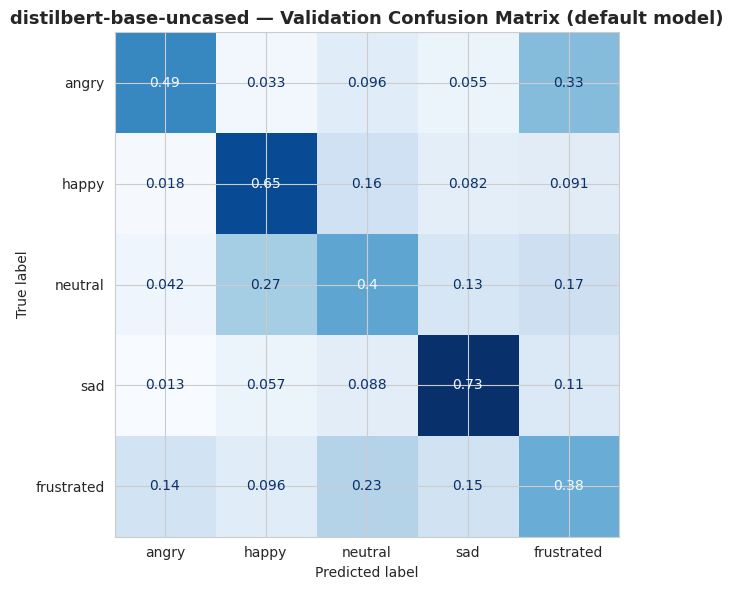

Saved: bert_text_default_val_confusion_matrix.png


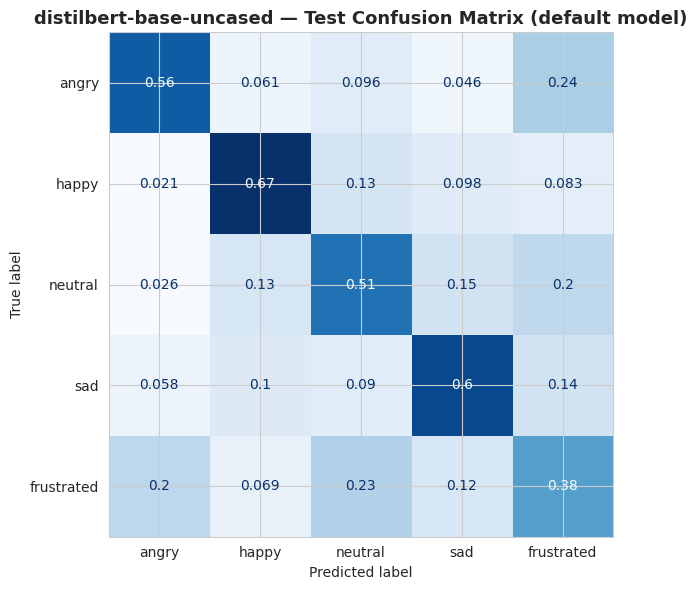

Saved: bert_text_default_test_confusion_matrix.png


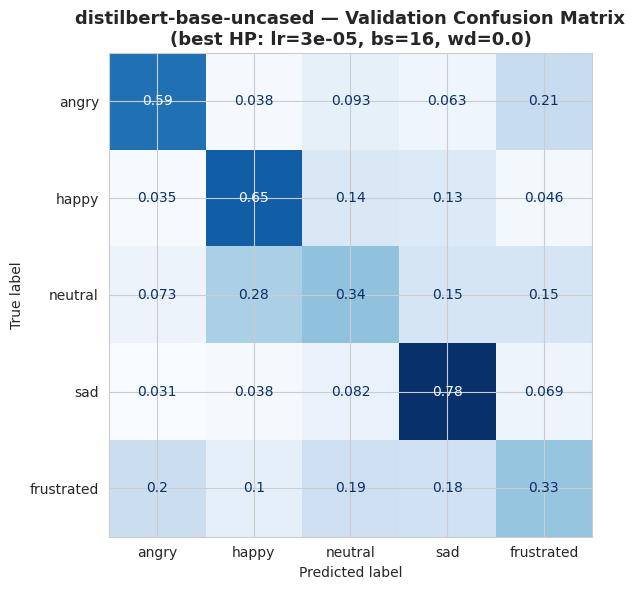

Saved: bert_text_val_confusion_matrix.png


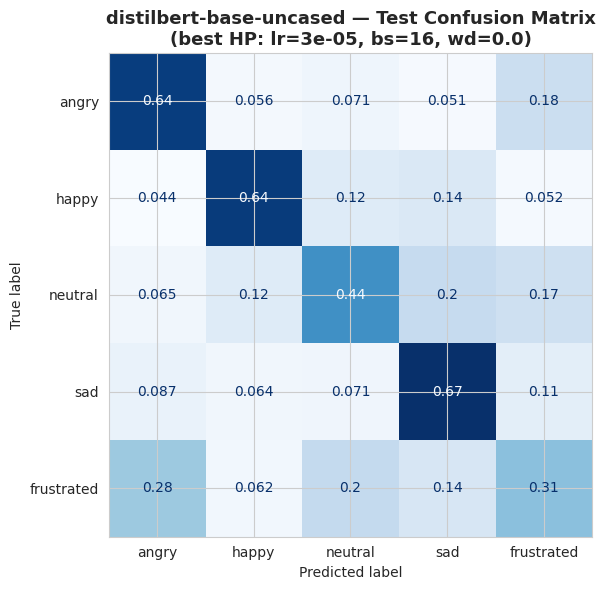

Saved: bert_text_test_confusion_matrix.png


In [16]:
# ── Default model confusion matrices (intermediate baseline) ──────────────
for _res, _sname, _fname in [
    (val_results,  'Validation', 'bert_text_default_val_confusion_matrix.png'),
    (test_results, 'Test',       'bert_text_default_test_confusion_matrix.png'),
]:
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        _res['true_ids'], _res['pred_ids'],
        labels=list(range(5)), display_labels=KEEP_EMOTIONS,
        normalize='true', cmap='Blues', ax=ax, colorbar=False,
    )
    _t = f'{MODEL_NAME} — {_sname} Confusion Matrix (default model)'
    if DEBUG_MODE: _t += '  [DEBUG]'
    ax.set_title(_t, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, _fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {_fname}')

# ── Standard confusion matrix files → final selected (best HP) model ──────
_hp_ready = (RUN_HPARAM_SEARCH
             and 'best_val_results'  in globals()
             and 'best_test_results' in globals()
             and best_val_results is not None)
_cm_val   = best_val_results  if _hp_ready else val_results
_cm_test  = best_test_results if _hp_ready else test_results
_cm_tag   = (f'best HP: lr={BEST_LR:.0e}, bs={BEST_BATCH_SIZE}, wd={BEST_WEIGHT_DECAY}'
             if (_hp_ready and 'BEST_LR' in globals()) else 'default model')

for _res, _sname, _fname in [
    (_cm_val,  'Validation', 'bert_text_val_confusion_matrix.png'),
    (_cm_test, 'Test',       'bert_text_test_confusion_matrix.png'),
]:
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        _res['true_ids'], _res['pred_ids'],
        labels=list(range(5)), display_labels=KEEP_EMOTIONS,
        normalize='true', cmap='Blues', ax=ax, colorbar=False,
    )
    _t = f'{MODEL_NAME} — {_sname} Confusion Matrix\n({_cm_tag})'
    if DEBUG_MODE: _t += '  [DEBUG]'
    ax.set_title(_t, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUTS_DIR, _fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {_fname}')


**Interpretation:**\
Normalised confusion matrices show per-class recall on the diagonal and systematic
confusions off-diagonal. DistilBERT contextual embeddings can partially capture
discourse structure and valence cues that bag-of-words models miss — for example,
`neutral` and `frustrated` share overlapping surface vocabulary but differ in discourse
structure. Persistent `angry`–`frustrated` confusions are expected: both classes use
direct, negatively-valenced vocabulary, and the distinction is primarily prosodic
rather than lexical.


---
## 7. Export Final Predictions and Metrics

The **standard final filenames** are written from the **best hyperparameter-search model**
(selected by Validation UAR in Section 5.5). If the HP search was skipped, the default
model is used as a fallback.

Probability columns are ordered `prob_angry … prob_frustrated`, matching `KEEP_EMOTIONS`
exactly, so the fusion notebook can align audio and text predictions row-by-row.

**Standard fusion export files (best HP model):**
- `bert_text_val_predictions_with_probs.csv`
- `bert_text_test_predictions_with_probs.csv`
- `bert_text_final_metrics.json`


In [17]:
# ── Export fusion-ready predictions ───────────────────────────────────────
# Standard final filenames are written from the best HP model (selected by
# Validation UAR). Falls back to the default model if HP search was skipped.
_use_best = (RUN_HPARAM_SEARCH
             and 'best_val_results'  in dir()
             and 'best_test_results' in dir()
             and len(hparam_df) > 0)

_final_val_results  = best_val_results  if _use_best else val_results
_final_test_results = best_test_results if _use_best else test_results

if _use_best:
    print('Exporting BEST HP model predictions as the final fusion files.')
else:
    print('Exporting DEFAULT model predictions (HP search was skipped).')

def make_pred_csv(df_part, results):
    probs    = results['probs']     # (N, 5) — column i = KEEP_EMOTIONS[i]
    pred_ids = results['pred_ids']
    true_ids = results['true_ids']

    out = pd.DataFrame({
        'orig_idx':      df_part['orig_idx'].values,
        'file':          df_part['file'].values,
        'true_label_id': true_ids,
        'pred_label_id': pred_ids,
        'true_emotion':  [ID2LABEL[i] for i in true_ids],
        'pred_emotion':  [ID2LABEL[i] for i in pred_ids],
        'correct':       (true_ids == pred_ids),
    })
    for i, emo in enumerate(KEEP_EMOTIONS):
        out[f'prob_{emo}'] = probs[:, i]

    prob_cols = [f'prob_{e}' for e in KEEP_EMOTIONS]
    prob_sums = out[prob_cols].sum(axis=1)
    assert (prob_sums - 1).abs().max() < 0.01, 'Probability rows do not sum to 1!'
    return out

# Standard final filenames → best HP model (or default fallback)
val_pred_df  = make_pred_csv(val_df,  _final_val_results)
test_pred_df = make_pred_csv(test_df, _final_test_results)

val_pred_df.to_csv(os.path.join(OUTPUTS_DIR,  'bert_text_val_predictions_with_probs.csv'),  index=False)
test_pred_df.to_csv(os.path.join(OUTPUTS_DIR, 'bert_text_test_predictions_with_probs.csv'), index=False)

print(f'Saved: bert_text_val_predictions_with_probs.csv   shape={val_pred_df.shape}')
print(f'Saved: bert_text_test_predictions_with_probs.csv  shape={test_pred_df.shape}')
print('Probability sums verified (all ≈ 1.0)')
if DEBUG_MODE:
    print('[DEBUG] Prediction files created — metrics are not meaningful.')


Exporting BEST HP model predictions as the final fusion files.
Saved: bert_text_val_predictions_with_probs.csv   shape=(2052, 12)
Saved: bert_text_test_predictions_with_probs.csv  shape=(2118, 12)
Probability sums verified (all ≈ 1.0)


In [18]:
# ── Per-class metrics and final metrics JSON ──────────────────────────────
# Uses the best HP model results if available; otherwise falls back to the
# default model. The JSON is the source of truth for the fusion notebook.
_use_best = (RUN_HPARAM_SEARCH
             and 'best_val_results'  in dir()
             and 'best_test_results' in dir()
             and len(hparam_df) > 0)

_final_val_results  = best_val_results  if _use_best else val_results
_final_test_results = best_test_results if _use_best else test_results
_best_lr = BEST_LR           if _use_best else LR
_best_bs = BEST_BATCH_SIZE   if _use_best else BATCH_SIZE
_best_wd = BEST_WEIGHT_DECAY if _use_best else WEIGHT_DECAY

# Per-class metrics on the test set (KEEP_EMOTIONS order)
report = classification_report(
    _final_test_results['true_ids'],
    _final_test_results['pred_ids'],
    labels=list(range(5)),
    target_names=KEEP_EMOTIONS,
    output_dict=True,
    zero_division=0,
)
per_class_df = pd.DataFrame([
    {
        'emotion':   emo,
        'precision': round(report[emo]['precision'], 4),
        'recall':    round(report[emo]['recall'],    4),
        'f1_score':  round(report[emo]['f1-score'],  4),
        'support':   int(report[emo]['support']),
    }
    for emo in KEEP_EMOTIONS
])
per_class_df.to_csv(os.path.join(OUTPUTS_DIR, 'bert_text_per_class_metrics.csv'), index=False)
print('Saved: bert_text_per_class_metrics.csv')
print(per_class_df.to_string(index=False))

# Final metrics JSON — always from the selected final model (best HP or default)
final_metrics = {
    'model':             MODEL_NAME,
    'selection_method':  'best_hp_search_val_uar' if _use_best else 'default',
    'learning_rate':     _best_lr,
    'batch_size':        _best_bs,
    'weight_decay':      _best_wd,
    'epochs':            EPOCHS,
    'warmup_ratio':      WARMUP_RATIO,
    'val_uar':           _final_val_results['metrics']['uar'],
    'val_macro_f1':      _final_val_results['metrics']['macro_f1'],
    'val_weighted_f1':   _final_val_results['metrics']['weighted_f1'],
    'val_accuracy':      _final_val_results['metrics']['accuracy'],
    'test_uar':          _final_test_results['metrics']['uar'],
    'test_macro_f1':     _final_test_results['metrics']['macro_f1'],
    'test_weighted_f1':  _final_test_results['metrics']['weighted_f1'],
    'test_accuracy':     _final_test_results['metrics']['accuracy'],
    'num_train_samples': len(train_df),
    'num_val_samples':   len(val_df),
    'num_test_samples':  len(test_df),
    'label_order':       KEEP_EMOTIONS,
    'seed':              RANDOM_SEED,
    'debug_mode':        DEBUG_MODE,
}
with open(os.path.join(OUTPUTS_DIR, 'bert_text_final_metrics.json'), 'w') as _f:
    json.dump(final_metrics, _f, indent=2)
print('\nSaved: bert_text_final_metrics.json')
print(f'  val_uar   = {final_metrics["val_uar"]:.4f}')
print(f'  test_uar  = {final_metrics["test_uar"]:.4f}')
print(f'  test_acc  = {final_metrics["test_accuracy"]:.4f}')
print(f'  test_f1   = {final_metrics["test_macro_f1"]:.4f}')
print(f'  source    : {final_metrics["selection_method"]}')


Saved: bert_text_per_class_metrics.csv
   emotion  precision  recall  f1_score  support
     angry     0.3342  0.6396    0.4390      197
     happy     0.7730  0.6444    0.7028      613
   neutral     0.4187  0.4404    0.4293      386
       sad     0.4466  0.6720    0.5366      311
frustrated     0.5281  0.3077    0.3888      611

Saved: bert_text_final_metrics.json
  val_uar   = 0.5369
  test_uar  = 0.5408
  test_acc  = 0.5137
  test_f1   = 0.4993
  source    : best_hp_search_val_uar


In [19]:
best_model_dir = os.path.join(OUTPUTS_DIR, 'best_model')

_final_trainer = (
    best_trainer
    if (RUN_HPARAM_SEARCH
        and 'best_trainer' in globals()
        and best_trainer is not None)
    else trainer
)

_final_trainer.save_model(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

_saved_which = ('best HP model' if _final_trainer is not trainer else 'default model')
print(f'Final selected model ({_saved_which}) and tokenizer saved to: {best_model_dir}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final selected model (best HP model) and tokenizer saved to: /content/drive/MyDrive/IEMOCAP_project/outputs/bert_text/best_model


---
## 8. Fusion-Readiness Sanity Check

Verifies that all expected output files exist; both prediction CSVs contain the five
`prob_` columns summing to 1; `orig_idx` and `file` are present for the fusion join;
and `KEEP_EMOTIONS` order is correct.


In [20]:
print('=' * 60)
print('FUSION READINESS SANITY CHECK')
print('=' * 60)

_all_ok = True

def _check(condition, fail_msg, ok_msg=None):
    global _all_ok
    if condition:
        print(f'  OK    {ok_msg or fail_msg}')
    else:
        print(f'  FAIL  {fail_msg}')
        _all_ok = False

# Required output files
_required = [
    'bert_text_val_predictions_with_probs.csv',
    'bert_text_test_predictions_with_probs.csv',
    'bert_text_final_metrics.json',
    'bert_text_per_class_metrics.csv',
    'bert_text_val_confusion_matrix.png',
    'bert_text_test_confusion_matrix.png',
]
for _fname in _required:
    _fpath = os.path.join(OUTPUTS_DIR, _fname)
    _check(os.path.exists(_fpath), f'{_fname} missing', f'{_fname} exists')

_val_csv  = pd.read_csv(os.path.join(OUTPUTS_DIR, 'bert_text_val_predictions_with_probs.csv'))
_test_csv = pd.read_csv(os.path.join(OUTPUTS_DIR, 'bert_text_test_predictions_with_probs.csv'))

_prob_cols = [f'prob_{e}' for e in KEEP_EMOTIONS]
_check(all(c in _val_csv.columns  for c in _prob_cols),
       'Probability columns missing in val CSV',
       f'Probability columns present: {_prob_cols}')
_check(all(c in _test_csv.columns for c in _prob_cols),
       'Probability columns missing in test CSV',
       'Probability columns present in test CSV')

_val_sum  = _val_csv[_prob_cols].sum(axis=1)
_test_sum = _test_csv[_prob_cols].sum(axis=1)
_check((_val_sum  - 1).abs().max() < 0.01, 'Val prob rows do not sum to 1',  'Val prob sums ≈ 1')
_check((_test_sum - 1).abs().max() < 0.01, 'Test prob rows do not sum to 1', 'Test prob sums ≈ 1')

_check('orig_idx' in _val_csv.columns, 'orig_idx missing in val CSV', 'orig_idx present')
_check('file'     in _val_csv.columns, 'file missing in val CSV',     'file present')

_check(KEEP_EMOTIONS == ['angry', 'happy', 'neutral', 'sad', 'frustrated'],
       'KEEP_EMOTIONS order incorrect',
       f'Label order correct: {KEEP_EMOTIONS}')

_check(len(_val_csv)  > 0, 'val predictions empty',  f'val predictions: {len(_val_csv)} rows')
_check(len(_test_csv) > 0, 'test predictions empty', f'test predictions: {len(_test_csv)} rows')

print()
print(f'  DEBUG_MODE = {DEBUG_MODE}')
print()
if _all_ok:
    if DEBUG_MODE:
        print('BERT text notebook smoke test completed successfully.')
    else:
        print('BERT text notebook is fusion-ready.')
else:
    _missing = [f for f in _required if not os.path.exists(os.path.join(OUTPUTS_DIR, f))]
    if _missing:
        print(f'SANITY CHECK FAILED. Missing files: {_missing}')
    else:
        print('SANITY CHECK FAILED — see FAIL lines above.')


FUSION READINESS SANITY CHECK
  OK    bert_text_val_predictions_with_probs.csv exists
  OK    bert_text_test_predictions_with_probs.csv exists
  OK    bert_text_final_metrics.json exists
  OK    bert_text_per_class_metrics.csv exists
  OK    bert_text_val_confusion_matrix.png exists
  OK    bert_text_test_confusion_matrix.png exists
  OK    Probability columns present: ['prob_angry', 'prob_happy', 'prob_neutral', 'prob_sad', 'prob_frustrated']
  OK    Probability columns present in test CSV
  OK    Val prob sums ≈ 1
  OK    Test prob sums ≈ 1
  OK    orig_idx present
  OK    file present
  OK    Label order correct: ['angry', 'happy', 'neutral', 'sad', 'frustrated']
  OK    val predictions: 2052 rows
  OK    test predictions: 2118 rows

  DEBUG_MODE = False

BERT text notebook is fusion-ready.


---
## Final Conclusions

### Results Summary

The final DistilBERT text model was selected using Validation UAR after hyperparameter
search. It achieved **Validation UAR = 0.5369** and **Test UAR = 0.5408**, with
Test Accuracy = 0.5137 and Test Macro F1 = 0.4993. This confirms that transcript
semantics provide strong emotion information and supports the later multimodal fusion
step with the HuBERT audio model.

### Cross-Modality Comparison

| System | Test UAR | Test Macro F1 |
|--------|----------|---------------|
| HuBERT Audio | 0.4952 | 0.4752 |
| **DistilBERT Text (this notebook)** | **0.5408** | **0.4993** |
| Late Fusion | **0.5895** | **0.5606** |

DistilBERT text outperformed the HuBERT audio-only model in Test UAR, but the final
late-fusion model achieved the best overall performance. Audio and text provide
complementary emotional information — audio captures prosody and speaking rate, while
text captures lexical and discourse-structural emotion cues.

### Reproducibility Notes

- **Split contract:** The split is defined in `shared_split_indices.csv` using
  session-disjoint boundaries (Train = Ses01–03, Val = Ses04, Test = Ses05). Do not
  create a local random split inside this notebook — it would violate speaker independence
  and inflate reported UAR scores.
- **DEBUG_MODE:** Set to `False` for the real run. Debug mode subsamples the data to
  ~100/50/50 samples and uses 1 epoch; metrics in debug mode are not meaningful.
- **GPU runtime:** A GPU runtime is recommended. `DEBUG_MODE = True` allows CPU-only testing.
- **Expected performance:** Standalone text UAR on IEMOCAP is expected to be 0.45–0.55
  due to the lexical ceiling: emotions are conveyed primarily through prosody, which is
  absent from transcripts. The real payoff is in late fusion with HuBERT audio predictions.
